# Diffusion Model — Test Single Sample
**Deep Learning Spring 2025 — Assignment 5 (Bonus)**  
**Student:** Maria | **Roll No:** MSDS25012

Loads the trained model from Drive, starts from pure Gaussian noise, runs 1000 reverse diffusion steps, displays the result.

In [26]:
# Cell 1: Mount Drive + imports
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

MODEL_PATH = '/content/drive/MyDrive/DLSpring2025_Assignment5/models_v3/best_model.pth'
SAVE_DIR   = '/content/drive/MyDrive/DLSpring2025_Assignment5/models_v3'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu


In [27]:
# Cell 2: Architecture definitions
class SinusoidalPositionEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None] * emb[None, :]
        return torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim=None):
        super().__init__()
        self.conv1     = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.norm1     = nn.GroupNorm(8, out_channels)
        self.conv2     = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.norm2     = nn.GroupNorm(8, out_channels)
        self.act       = nn.SiLU()
        self.time_proj = nn.Linear(time_emb_dim, out_channels) if time_emb_dim else None
        self.skip      = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
    def forward(self, x, t_emb=None):
        h = self.act(self.norm1(self.conv1(x)))
        if self.time_proj is not None and t_emb is not None:
            h = h + self.time_proj(t_emb)[:, :, None, None]
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.skip(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, base_channels=32,   # CHANGED from 64
                 time_emb_dim=256, num_res_blocks=2, channel_mults=(1, 2, 4)):
        super().__init__()
        self.time_embedding = SinusoidalPositionEmbedding(time_emb_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim * 4), nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim))
        self.init_conv = nn.Conv2d(in_channels, base_channels, 3, padding=1)
        self.encoder_levels    = nn.ModuleList()
        self.downsamplers      = nn.ModuleList()
        self._enc_out_channels = []
        ch = base_channels
        for i, mult in enumerate(channel_mults):
            out_ch = base_channels * mult
            level  = nn.ModuleList()
            for _ in range(num_res_blocks):
                level.append(ResidualBlock(ch, out_ch, time_emb_dim))
                ch = out_ch
            self.encoder_levels.append(level)
            self._enc_out_channels.append(ch)
            if i < len(channel_mults) - 1:
                self.downsamplers.append(nn.Sequential(nn.Conv2d(ch, ch, 3, stride=2, padding=1), nn.SiLU()))
            else:
                self.downsamplers.append(nn.Identity())
        self.bottleneck1 = ResidualBlock(ch, ch, time_emb_dim)
        self.bottleneck2 = ResidualBlock(ch, ch, time_emb_dim)
        self.decoder_levels = nn.ModuleList()
        self.upsamplers     = nn.ModuleList()
        for i, mult in enumerate(reversed(channel_mults)):
            out_ch  = base_channels * mult
            skip_ch = self._enc_out_channels[-(i + 1)]
            level   = nn.ModuleList()
            for j in range(num_res_blocks + 1):
                in_ch = (ch + skip_ch) if j == 0 else out_ch
                level.append(ResidualBlock(in_ch, out_ch, time_emb_dim))
                ch = out_ch
            self.decoder_levels.append(level)
            if i < len(channel_mults) - 1:
                self.upsamplers.append(nn.Sequential(nn.ConvTranspose2d(ch, ch, 4, stride=2, padding=1), nn.SiLU()))
            else:
                self.upsamplers.append(nn.Identity())
        self.final_conv = nn.Sequential(
            nn.GroupNorm(8, base_channels), nn.SiLU(),
            nn.Conv2d(base_channels, out_channels, 3, padding=1))
    def forward(self, x, t):
        t_emb = self.time_mlp(self.time_embedding(t))
        h = self.init_conv(x)
        skips = []
        for level_blocks, downsampler in zip(self.encoder_levels, self.downsamplers):
            for block in level_blocks: h = block(h, t_emb)
            skips.append(h)
            h = downsampler(h)
        h = self.bottleneck1(h, t_emb)
        h = self.bottleneck2(h, t_emb)
        for level_blocks, upsampler in zip(self.decoder_levels, self.upsamplers):
            skip = skips.pop()
            h = torch.cat([h, skip], dim=1)
            for block in level_blocks: h = block(h, t_emb)
            h = upsampler(h)
        return self.final_conv(h)

print('Architecture ready.')

Architecture ready.


In [28]:
# Cell 3: Load trained model
T = 1000
betas      = torch.linspace(0.0001, 0.02, T, device=device)
alphas     = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
sqrt_one_minus_ab = torch.sqrt(1 - alpha_bars)

model = UNet(base_channels=32).to(device)              # CHANGED: explicit base_channels=32
ckpt  = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(ckpt['ema_model_state_dict'])    # CHANGED: ema_model_state_dict instead of model_state_dict
model.eval()
print(f'Loaded epoch {ckpt["epoch"]+1}, loss {ckpt["loss"]:.4f}')

Loaded epoch 108, loss 0.0979


In [29]:
# Cell 4: Generate one image from pure noise
x = torch.randn(1, 3, 64, 64, device=device)
snapshots = {}

with torch.no_grad():
    for t in tqdm(range(T-1, -1, -1), desc='Denoising'):
        t_t        = torch.full((1,), t, device=device, dtype=torch.long)
        noise_pred = model(x, t_t)
        beta       = betas[t_t].view(-1,1,1,1)
        alpha      = alphas[t_t].view(-1,1,1,1)
        s1ab       = sqrt_one_minus_ab[t_t].view(-1,1,1,1)
        x = (1.0/torch.sqrt(alpha))*(x - (1-alpha)/s1ab*noise_pred)
        if t > 0:
            x = x + torch.sqrt(beta)*torch.randn_like(x)
        if t in [999, 800, 600, 400, 200, 100, 50, 0]:
            snapshots[t] = x.clone().cpu()

print('Done!')

Denoising: 100%|██████████| 1000/1000 [01:44<00:00,  9.55it/s]

Done!


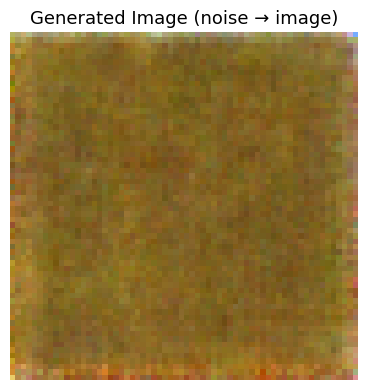

In [30]:
import os

def to_img(t):
    img = t[0].cpu().float()
    # Min-max normalize so any output range becomes visible
    img = img - img.min()
    img = img / (img.max() + 1e-8)
    return img.permute(1, 2, 0).numpy()

os.makedirs(SAVE_DIR, exist_ok=True)

plt.figure(figsize=(4,4))
plt.imshow(to_img(x.cpu()))
plt.axis('off')
plt.title('Generated Image (noise → image)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'test_generated.png'), dpi=150, bbox_inches='tight')
plt.show()

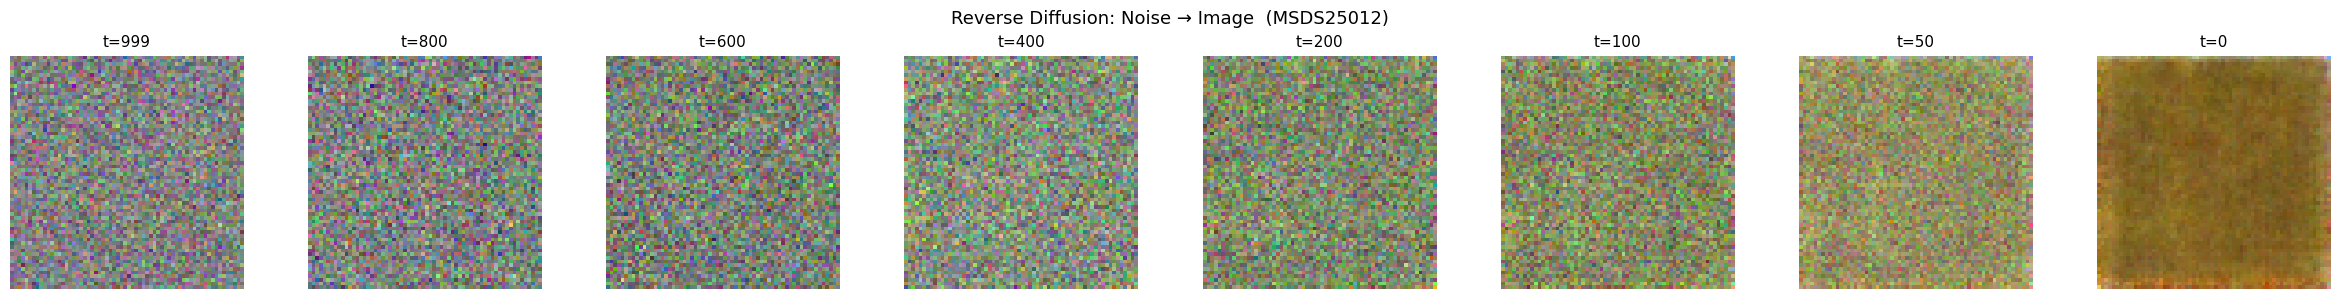

Saved!


In [31]:
steps = [999, 800, 600, 400, 200, 100, 50, 0]
fig, axes = plt.subplots(1, len(steps), figsize=(len(steps)*3, 3))
for ax, t in zip(axes, steps):
    ax.imshow(to_img(snapshots[t]))
    ax.set_title(f't={t}', fontsize=11)
    ax.axis('off')
plt.suptitle('Reverse Diffusion: Noise → Image  (MSDS25012)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'test_reverse_process.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')